## Latent Diffusion + ControlNet for Image Enhancement

This project implements a **latent diffusion-based image enhancement pipeline** using a **ControlNet-style conditioning approach**.

### Key Idea
Enhance a low-quality (LQ) image by guiding a **frozen pretrained latent diffusion model** using a **trainable ControlNet**.

---

### Components

- **Frozen VAE**  
  Encodes/decodes images to/from latent space

- **Frozen UNet (Diffusion Model)**  
  Predicts noise during denoising

- **Trainable ControlNet**  
  Takes LQ image → produces residuals to guide UNet

---

### Frozen Weights Source

Loaded from a pretrained latent diffusion model:
- Stable Diffusion 

In [13]:
import sys
import os
import time
import math
from enum import Enum
from functools import partial

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from pathlib import Path
import subprocess
import textwrap

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0


In [14]:
cpu_device = torch.device("cpu")

cuda_available = torch.cuda.is_available()
mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

if cuda_available:
    accel_device = torch.device("cuda")
elif mps_available:
    accel_device = torch.device("mps")
else:
    accel_device = cpu_device

has_accel = accel_device.type != "cpu"
print(f"Accelerator available: {has_accel}")
print(f"Preferred accelerator: {accel_device}")

Accelerator available: True
Preferred accelerator: mps


In [15]:
def _ensure_src_on_path() -> Path:
    """Add the project's `src/` directory to sys.path and return project root."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "src").is_dir():
            sys.path.insert(0, str(p / "src"))
            return p
    raise RuntimeError("Could not find a `src/` directory in current or parent paths")

# Load and run baseline pipeline from Hugging Face

Use Hugging Face Diffusers to load a pretrained Stable Diffusion model.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

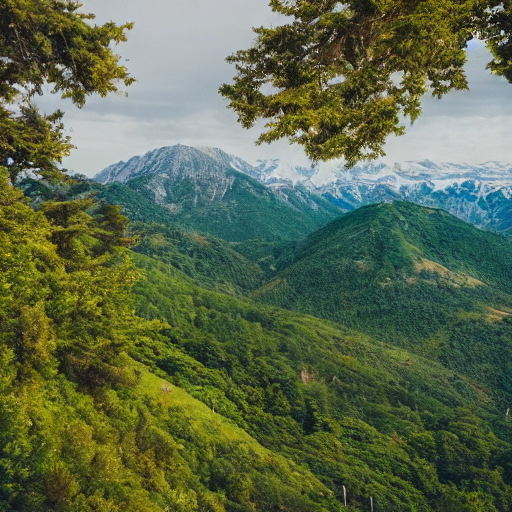

In [16]:
from diffusers import StableDiffusionPipeline
import torch

# Create the pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(accel_device)

# --- Extract and save the components we need ---
vae = pipe.vae
unet = pipe.unet
scheduler = pipe.scheduler

# Generate a sample image to verify it works
image = pipe("a high quality photo of a landscape").images[0]

# --- Clean up the pipeline to save memory ---
del pipe

device_type = getattr(accel_device, "type", str(accel_device))
if device_type == "cuda":
    torch.cuda.empty_cache()
elif device_type == "mps" and hasattr(torch, "mps"):
    torch.mps.empty_cache()

# Display the sample image
image

In [17]:
# Freeze these parts so they don't get updated during training
for p in vae.parameters():
    p.requires_grad = False

for p in unet.parameters():
    p.requires_grad = False

In [18]:
# Use a random latent and pass it through the UNet as a quick sanity check.
# Note: match dtype/device to the model; run under inference mode to reduce memory use.

unet.eval()

device = accel_device
dtype = next(unet.parameters()).dtype

latents = torch.randn((1, 4, 64, 64), device=device, dtype=dtype)
t = torch.tensor(50, device=device, dtype=torch.long)
text_embeddings_placeholder = torch.randn((1, 77, 768), device=device, dtype=dtype)

with torch.inference_mode():
    noise_pred = unet(latents, t, encoder_hidden_states=text_embeddings_placeholder).sample

noise_pred.shape

torch.Size([1, 4, 64, 64])

In [19]:
# --- Download DIV2K (HR) via kagglehub ---
import sys
import subprocess
from pathlib import Path

def _ensure_kagglehub() -> None:
    try:
        import kagglehub  # noqa: F401
        return
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)

_ensure_kagglehub()
import kagglehub  # noqa: E402

path = kagglehub.dataset_download("soumikrakshit/div2k-high-resolution-images")
dataset_root = Path(path)
print("Path to dataset files:", dataset_root)

Path to dataset files: /Users/ryankoes/.cache/kagglehub/datasets/soumikrakshit/div2k-high-resolution-images/versions/1


In [20]:
# Encode images to latent space (connect dataset -> VAE)
from pathlib import Path

import torch

project_root = _ensure_src_on_path()

from diffusers import AutoencoderKL
from ldm_controlnet_engine.data.dataset import HQToLQDataset, PairTransform, default_div2k_hq_root

def _find_any_images(root: Path) -> bool:
    return any(root.rglob("*.png")) or any(root.rglob("*.jpg")) or any(root.rglob("*.jpeg"))

# Ensure we have a VAE in memory (reload-safe)
if "vae" not in globals():
    torch_dtype = torch.float16 if accel_device.type in {"cuda", "mps"} else torch.float32
    vae = AutoencoderKL.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        subfolder="vae",
        torch_dtype=torch_dtype,
    ).to(accel_device)
    for p in vae.parameters():
        p.requires_grad = False

# Build paired (LQ, HQ) samples; SD v1.5 VAE expects inputs in [-1, 1].
transform = PairTransform(crop_size=512, random_crop=True, normalize=True)

# Prefer kagglehub download path if available; otherwise use workspace cache
hq_root = None
if "dataset_root" in globals():
    try:
        candidate = Path(dataset_root)
        if candidate.exists() and _find_any_images(candidate):
            hq_root = candidate
            print(f"Using kagglehub dataset_root: {hq_root}")
    except Exception:
        pass
if hq_root is None:
    hq_root = default_div2k_hq_root(project_root)

try:
    dataset = HQToLQDataset(hq_root=hq_root, transform=transform, seed=42)
except FileNotFoundError as e:
    print(f"Could not load images from {hq_root} ({e}).")
    hq_root = project_root / "notebooks"
    print(f"Falling back to: {hq_root}")
    dataset = HQToLQDataset(hq_root=hq_root, transform=transform, seed=42)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0, pin_memory=has_accel)

batch = next(iter(loader))
x_lq = batch["lq"]
x_hq = batch["hq"]

vae.eval()
vae_dtype = next(vae.parameters()).dtype
device = accel_device

# Move tensors to same dtype/device as VAE
x_lq = x_lq.to(device=device, dtype=vae_dtype)
x_hq = x_hq.to(device=device, dtype=vae_dtype)

with torch.no_grad():
    z_hq = vae.encode(x_hq).latent_dist.sample() * 0.18215
    z_lq = vae.encode(x_lq).latent_dist.sample() * 0.18215

print("hq_root:", str(hq_root))
print("x_hq:", tuple(x_hq.shape), x_hq.dtype, x_hq.device)
print("z_hq:", tuple(z_hq.shape), z_hq.dtype, z_hq.device)
print("x_lq:", tuple(x_lq.shape), x_lq.dtype, x_lq.device)
print("z_lq:", tuple(z_lq.shape), z_lq.dtype, z_lq.device)

Using kagglehub dataset_root: /Users/ryankoes/.cache/kagglehub/datasets/soumikrakshit/div2k-high-resolution-images/versions/1
hq_root: /Users/ryankoes/.cache/kagglehub/datasets/soumikrakshit/div2k-high-resolution-images/versions/1
x_hq: (1, 3, 512, 512) torch.float16 mps:0
z_hq: (1, 4, 64, 64) torch.float16 mps:0
x_lq: (1, 3, 512, 512) torch.float16 mps:0
z_lq: (1, 4, 64, 64) torch.float16 mps:0


In [21]:
# Forward diffusion: q(z_t | z_0) using the scheduler
import torch

# Ensure scheduler is available (reload-safe)
if "scheduler" not in globals():
    from diffusers import DDPMScheduler
    scheduler = DDPMScheduler.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        subfolder="scheduler",
    )

if "z_hq" not in globals():
    raise RuntimeError("Run the previous cell to compute `z_hq` first.")

device = z_hq.device
batch_size = z_hq.shape[0]

# Sample random diffusion timesteps in [0, num_train_timesteps)
num_train_timesteps = int(getattr(scheduler.config, "num_train_timesteps", 1000))
t = torch.randint(0, num_train_timesteps, (batch_size,), device=device, dtype=torch.long)

noise = torch.randn_like(z_hq)
z_t = scheduler.add_noise(z_hq, noise, t)

print("t:", t[:8].tolist())
print("z_hq:", tuple(z_hq.shape), z_hq.dtype, z_hq.device)
print("noise:", tuple(noise.shape), noise.dtype, noise.device)
print("z_t:", tuple(z_t.shape), z_t.dtype, z_t.device)

t: [931]
z_hq: (1, 4, 64, 64) torch.float16 mps:0
noise: (1, 4, 64, 64) torch.float16 mps:0
z_t: (1, 4, 64, 64) torch.float16 mps:0


In [12]:
# Minimal training loop sanity check (UNet noise prediction + MSE)
import torch
import torch.nn as nn
import torch.optim as optim

# Ensure UNet is available (reload-safe)
if "unet" not in globals():
    from diffusers import UNet2DConditionModel
    torch_dtype = torch.float16 if accel_device.type in {"cuda", "mps"} else torch.float32
    unet = UNet2DConditionModel.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        subfolder="unet",
        torch_dtype=torch_dtype,
    ).to(accel_device)

# Require previous forward diffusion outputs
missing = [name for name in ["z_t", "t", "noise"] if name not in globals()]
if missing:
    raise RuntimeError(f"Run the previous cell(s) first; missing: {missing}")

device = z_t.device
unet_dtype = next(unet.parameters()).dtype
z_t = z_t.to(device=device, dtype=unet_dtype)
noise = noise.to(device=device, dtype=unet_dtype)
t = t.to(device=device, dtype=torch.long)

# Stable Diffusion UNet is a *conditional* UNet: provide placeholder text embeddings
batch_size = z_t.shape[0]
seq_len = 77
cross_attention_dim = int(getattr(unet.config, "cross_attention_dim", 768))
encoder_hidden_states = torch.zeros((batch_size, seq_len, cross_attention_dim), device=device, dtype=unet_dtype)

# Keep this minimal: optimize a tiny scale parameter so backward/step is exercised
learnable_scale = nn.Parameter(torch.ones((), device=device, dtype=unet_dtype))
optimizer = optim.AdamW([learnable_scale], lr=1e-3)

unet.eval()  # just a functional sanity check
for step in range(3):
    optimizer.zero_grad(set_to_none=True)
    with torch.no_grad():
        noise_pred = unet(z_t, t, encoder_hidden_states=encoder_hidden_states).sample
    pred = learnable_scale * noise_pred
    loss = (pred - noise).float().pow(2).mean()
    loss.backward()
    optimizer.step()
    print(f"step={step} loss={loss.item():.6f} scale={learnable_scale.item():.4f}")

step=0 loss=0.570493 scale=0.9990
step=1 loss=0.570480 scale=0.9980
step=2 loss=0.570454 scale=0.9971
